# RAG Evaluation Analysis
Análisis de preferencias de respuesta generadas por el bot en modo evaluación.

**Secciones:**
1. Carga y vista general del CSV
2. Visualizar respuestas para una query concreta
3. Estadísticas globales de preferencia por modo
4. Evolución temporal de preferencias
5. Tabla detallada por query

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

# ── Estilos ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size': 11,
})

MODE_COLORS = {
    'semantic':     '#4C72B0',
    'hybrid':       '#DD8452',
    'language_aware_hybrid': '#C44E52',
    'no_retrieval': '#55A868',
}
MODE_LABELS = {
    'semantic':     '🔍 Semantic',
    'hybrid':       '⚡ Hybrid',
    'language_aware_hybrid': '🌐 Language-Aware Hybrid',
    'no_retrieval': '🧠 No retrieval',
}
print('Librerías cargadas.')

Librerías cargadas.


## 1. Carga del CSV

In [2]:
# ── Ajusta la ruta si es necesario ─────────────────────────────────────────
CSV_PATH = 'c:/Users/mamen/Documents/Python/RAGChatBot/eval/eval_results.csv'

df = pd.read_csv(CSV_PATH, parse_dates=['timestamp'])

# Normalizar preferred_mode por si hay variaciones de mayúsculas
df['preferred_mode'] = df['preferred_mode'].str.strip().str.lower()

print(f"Registros cargados: {len(df)}")
print(f"Rango de fechas:    {df['timestamp'].min()}  →  {df['timestamp'].max()}")
print(f"Usuarios únicos:    {df['user_id'].nunique()}")
print(f"Queries únicas:     {df['query'].nunique()}")
print(f"Columnas:           {df.columns.tolist()}")
print()
display(df[['timestamp','user_id','query','preferred_mode']].head(10))

Registros cargados: 8
Rango de fechas:    2026-03-09T12:43:18.795819  →  2026-03-13T09:45:00.441471+00:00
Usuarios únicos:    1
Queries únicas:     8
Columnas:           ['timestamp', 'user_id', 'query', 'preferred_mode', 'answer_semantic', 'answer_hybrid', 'answer_language_aware_hybrid', 'answer_no_retrieval']



,timestamp,user_id,query,preferred_mode
0,2026-03-09T12:43:18.795819,5262330082,¿Qué tratamiento es más común para el cancer d...,hybrid
1,2026-03-09T13:05:31.710186+00:00,5262330082,¿cuándo se necesita una biopsia del tumor?,no_retrieval
2,2026-03-09T13:07:17.773967+00:00,5262330082,¿Qué pruebas son necesarias para diagnosticar ...,language_aware_hybrid
3,2026-03-09T13:09:02.634701+00:00,5262330082,¿Cómo va a impactar mi diagnóstico de cancer d...,hybrid
4,2026-03-09T13:11:01.100686+00:00,5262330082,¿Cuáles son las particularidades del cancer de...,no_retrieval
5,2026-03-09T13:13:03.202674+00:00,5262330082,¿Cómo puedo decirle a mis hijos que tienen men...,language_aware_hybrid
6,2026-03-09T13:13:37.518917+00:00,5262330082,¿Qué es el cancer?,semantic
7,2026-03-13T09:45:00.441471+00:00,5262330082,Cuáles son los efectos de la quimioterapia?,language_aware_hybrid


In [16]:
display(df[['timestamp','user_id','query','preferred_mode', 'answer_semantic']].head(10))

,timestamp,user_id,query,preferred_mode,answer_semantic
0,2026-03-09T12:43:18.795819,5262330082,¿Qué tratamiento es más común para el cancer d...,hybrid,"No tengo una respuesta específica, pero el con..."
1,2026-03-09T13:05:31.710186+00:00,5262330082,¿cuándo se necesita una biopsia del tumor?,no_retrieval,"Según el contexto, se necesita una biopsia del..."
2,2026-03-09T13:07:17.773967+00:00,5262330082,¿Qué pruebas son necesarias para diagnosticar ...,language_aware_hybrid,"Según el contexto proporcionado, las pruebas n..."
3,2026-03-09T13:09:02.634701+00:00,5262330082,¿Cómo va a impactar mi diagnóstico de cancer d...,hybrid,"Según el texto proporcionado, el diagnóstico y..."
4,2026-03-09T13:11:01.100686+00:00,5262330082,¿Cuáles son las particularidades del cancer de...,no_retrieval,"Según el texto proporcionado, las particularid..."
5,2026-03-09T13:13:03.202674+00:00,5262330082,¿Cómo puedo decirle a mis hijos que tienen men...,language_aware_hybrid,Según el manual para pacientes oncológicos y s...
6,2026-03-09T13:13:37.518917+00:00,5262330082,¿Qué es el cancer?,semantic,"Según el texto proporcionado, el cáncer se def..."


## 2. Visualizar respuestas para una query concreta

In [4]:
# ── Lista de queries disponibles ───────────────────────────────────────────
queries = df['query'].unique()
print("Queries disponibles:")
for i, q in enumerate(queries):
    print(f"  [{i}] {q}")

Queries disponibles:
  [0] ¿Qué tratamiento es más común para el cancer de mama?
  [1] ¿cuándo se necesita una biopsia del tumor?
  [2] ¿Qué pruebas son necesarias para diagnosticar un cancer de mama?
  [3] ¿Cómo va a impactar mi diagnóstico de cancer de mama a mi sexualidad?
  [4] ¿Cuáles son las particularidades del cancer de mama HER2-positivo?
  [5] ¿Cómo puedo decirle a mis hijos que tienen menos de 5 años que tengo cancer?
  [6] ¿Qué es el cancer?
  [7] Cuáles son los efectos de la quimioterapia?


In [6]:
# ── Selecciona query por índice o escribe directamente ─────────────────────
QUERY_IDX = 7          # ← cambia este número, o usa QUERY_TEXT abajo
QUERY_TEXT = None      # ← si se rellena, tiene preferencia sobre QUERY_IDX

selected_query = QUERY_TEXT if QUERY_TEXT else queries[QUERY_IDX]
subset = df[df['query'] == selected_query]

display(Markdown(f"### Query seleccionada\n> *{selected_query}*"))
print(f"Apariciones en el log: {len(subset)}\n")

# Mostrar las respuestas de la primera aparición
row = subset.iloc[0]
for mode in ['semantic', 'hybrid', 'language_aware_hybrid', 'no_retrieval']:
    label = MODE_LABELS.get(mode, mode)
    preferred_mark = ' ✅ preferida' if row['preferred_mode'] == mode else ''
    display(Markdown(
        f"---\n"
        f"**{label}{preferred_mark}**\n\n"
        f"{row[f'answer_{mode}']}"
    ))

### Query seleccionada
> *Cuáles son los efectos de la quimioterapia?*

Apariciones en el log: 1



---
**🔍 Semantic**

La quimioterapia puede tener varios efectos secundarios en diferentes áreas del cuerpo, como la médula ósea, los folículos pilosos, el sistema digestivo y el revestimiento de la boca. Algunos de los efectos secundarios más comunes son:

* Pérdida del cabello
* Fatiga
* Pérdida de apetito
* Náuseas y vómitos
* Diarrea o estreñimiento
* Llagas en la boca
* Cambios en la piel y las uñas
* Mayor riesgo de infecciones
* Daños en los nervios (neuropatía)
* Problemas con la función cognitiva (como la memoria y la concentración)

Es importante tener en cuenta que los efectos secundarios de la quimioterapia pueden variar dependiendo del tipo y dosis de los medicamentos utilizados, así como de la duración del tratamiento. La mayoría de estos efectos secundarios son temporales y pueden controlarse con medicamentos o cambios en el estilo de vida.

---
**⚡ Hybrid**

La quimioterapia puede causar varios efectos secundarios, que varían en función de los medicamentos y las dosis utilizadas. Algunos de los efectos secundarios más comunes incluyen:

- Pérdida del cabello
- Fatiga
- Pérdida de apetito
- Náuseas y vómitos
- Estreñimiento o diarrea
- Llagas en la boca
- Cambios en la piel y las uñas
- Mayor riesgo de infecciones
- Daños en los nervios (neuropatía)
- Problemas con la función cognitiva

La mayoría de estos efectos secundarios son temporales y pueden controlarse con medicamentos o cambios en el estilo de vida. Es importante hablar con el médico o enfermero especialista para saber cómo manejar cualquier efecto secundario que se produzca.

---
**🌐 Language-Aware Hybrid ✅ preferida**

La quimioterapia puede causar varios efectos secundarios, como:

* Pérdida del cabello (alopecia)
* Anemia (falta de glóbulos rojos)
* Astenia (debilidad)
* Aumento de las infecciones
* Daños tisulares relacionados con la extravasación (daños en la piel)
* Diarrea
* Náuseas y vómitos
* Pérdida de apetito
* Fatiga
* Llagas en la boca
* Cambios en la piel y las uñas
* Mayor riesgo de infecciones
* Daños en los nervios (neuropatía)
* Problemas de función cognitiva (memoria y concentración)

Es importante tener en cuenta que estos efectos secundarios pueden variar en función del tipo y dosis de los medicamentos utilizados, así como de la duración del tratamiento. La mayoría de estos efectos secundarios son temporales y pueden controlarse con medicamentos o cambios en el estilo de vida.

---
**🧠 No retrieval**

Los efectos de la quimioterapia pueden ser:

 * Náuseas y vómitos
 * Pérdida de cabello
 * Debilidad y fatiga
 * Infecciones y problemas de inmunidad
 * Diarrea y dolor abdominal
 * Náuseas y vómitos
 * Problemas en la médula ósea y la sangre
 * Problemas de memoria y concentración
 * Problemas de la vista y el oído
 * Problemas de la piel y la mucosa

Es importante mencionar que estos efectos pueden variar dependiendo de la dosis, el tipo de medicamento y la duración de la quimioterapia.

In [19]:
# ── Si la misma query aparece varias veces, mostrar preferencias acumuladas ─
if len(subset) > 1:
    pref_counts = subset['preferred_mode'].value_counts()
    display(Markdown(f"**Preferencias para esta query ({len(subset)} votos):**"))

    fig, ax = plt.subplots(figsize=(6, 3))
    colors = [MODE_COLORS.get(m, '#999') for m in pref_counts.index]
    bars = ax.barh([MODE_LABELS.get(m, m) for m in pref_counts.index],
                   pref_counts.values, color=colors, height=0.5)
    ax.bar_label(bars, padding=4)
    ax.set_xlabel('Votos')
    ax.set_title('Preferencia por modo — query seleccionada')
    plt.tight_layout()
    plt.show()
else:
    print('(Solo una aparición de esta query en el log.)')

(Solo una aparición de esta query en el log.)


## 3. Estadísticas globales de preferencia

In [20]:
counts = df['preferred_mode'].value_counts()
pct    = (counts / counts.sum() * 100).round(1)

summary = pd.DataFrame({'Votos': counts, 'Porcentaje (%)': pct})
summary.index = [MODE_LABELS.get(m, m) for m in summary.index]
display(summary)

winner = counts.idxmax()
print(f"\n🏆 Modo preferido global: {MODE_LABELS.get(winner, winner)} ({pct[winner]}%)")

,Votos,Porcentaje (%)
⚡ Hybrid,2,28.6
🧠 No retrieval,2,28.6
🌐 Language-Aware Hybrid,2,28.6
🔍 Semantic,1,14.3



🏆 Modo preferido global: ⚡ Hybrid (28.6%)


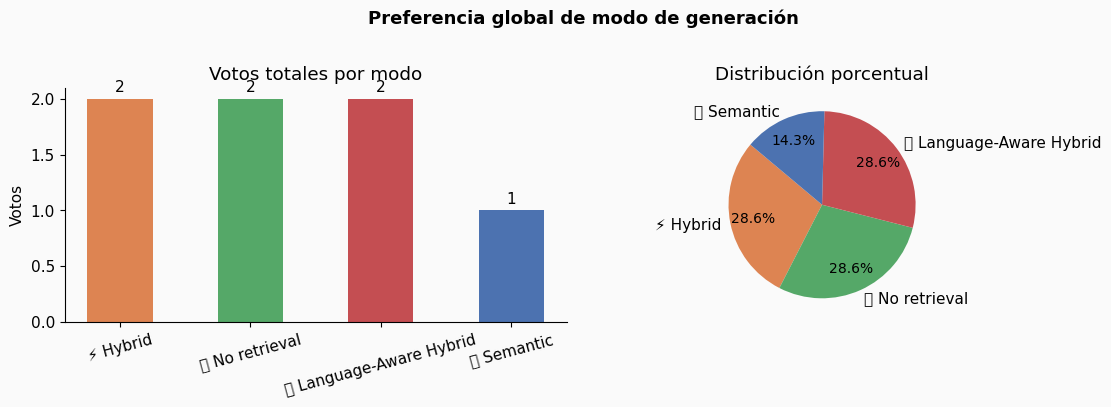

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
ax = axes[0]
colors = [MODE_COLORS.get(m, '#999') for m in counts.index]
bars = ax.bar([MODE_LABELS.get(m, m) for m in counts.index],
              counts.values, color=colors, width=0.5)
ax.bar_label(bars, padding=3)
ax.set_ylabel('Votos')
ax.set_title('Votos totales por modo')
ax.tick_params(axis='x', labelrotation=15)

# Pastel
ax2 = axes[1]
wedge_colors = [MODE_COLORS.get(m, '#999') for m in counts.index]
wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels=[MODE_LABELS.get(m, m) for m in counts.index],
    colors=wedge_colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(10)
ax2.set_title('Distribución porcentual')

plt.suptitle('Preferencia global de modo de generación', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Evolución temporal de preferencias

In [12]:
if len(df) < 2:
    print('Insuficientes datos para evolución temporal.')
else:
    df_sorted = df.sort_values('timestamp').copy()

    # Acumulado de votos por modo a lo largo del tiempo
    for mode in MODE_COLORS:
        df_sorted[f'cum_{mode}'] = (df_sorted['preferred_mode'] == mode).cumsum()

    fig, ax = plt.subplots(figsize=(10, 4))
    for mode, color in MODE_COLORS.items():
        ax.plot(df_sorted['timestamp'], df_sorted[f'cum_{mode}'],
                label=MODE_LABELS[mode], color=color, linewidth=2)

    ax.set_xlabel('Tiempo')
    ax.set_ylabel('Votos acumulados')
    ax.set_title('Evolución acumulada de preferencias')
    ax.legend()
    plt.tight_layout()
    plt.show()

Insuficientes datos para evolución temporal.


## 5. Tabla detallada por query

In [13]:
# Resumen: para cada query única, cuántas veces se evaluó y qué modo ganó
query_summary = (
    df.groupby('query')
    .agg(
        evaluaciones=('preferred_mode', 'count'),
        modo_ganador=('preferred_mode', lambda x: x.value_counts().idxmax()),
        votos_ganador=('preferred_mode', lambda x: x.value_counts().max()),
    )
    .reset_index()
    .sort_values('evaluaciones', ascending=False)
)

query_summary['modo_ganador'] = query_summary['modo_ganador'].map(
    lambda m: MODE_LABELS.get(m, m)
)

# Truncar queries largas para que la tabla sea legible
query_summary['query_corta'] = query_summary['query'].str[:70] + '…'

display(
    query_summary[['query_corta', 'evaluaciones', 'modo_ganador', 'votos_ganador']]
    .rename(columns={
        'query_corta': 'Query',
        'evaluaciones': 'Evaluaciones',
        'modo_ganador': 'Modo preferido',
        'votos_ganador': 'Votos del modo ganador',
    })
    .style.background_gradient(subset=['Evaluaciones'], cmap='Blues')
)

,Query,Evaluaciones,Modo preferido,Votos del modo ganador
0,¿Qué tratamiento es más común para el cancer de mama?…,1,⚡ Hybrid,1


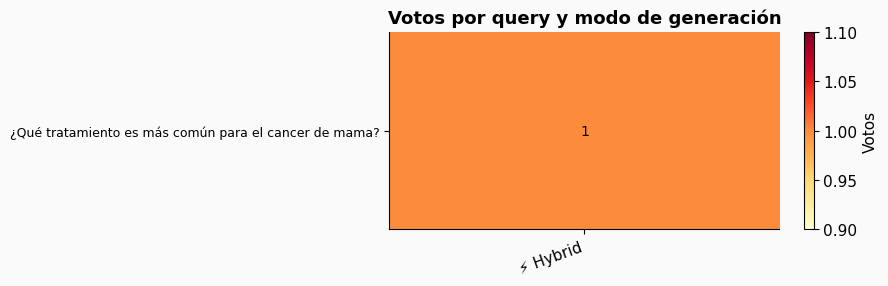

In [14]:
# Mapa de calor: queries (eje Y) × modo (eje X) → nº de votos
pivot = (
    df.groupby(['query', 'preferred_mode'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[m for m in MODE_COLORS if m in df['preferred_mode'].unique()], fill_value=0)
)

# Acortar etiquetas del eje Y
pivot.index = [q[:55] + '…' if len(q) > 55 else q for q in pivot.index]
pivot.columns = [MODE_LABELS.get(c, c) for c in pivot.columns]

fig, ax = plt.subplots(figsize=(9, max(3, len(pivot) * 0.55 + 1)))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Votos')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=20, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)

# Anotar celdas
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=10, color='black')

ax.set_title('Votos por query y modo de generación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()